![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [44]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [45]:
print(crimes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  object
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(2), object(10)
memory usage: 17.0+ MB
None


In [46]:
# Extract the hour from "TIME OCC" and store in a new column "HOUR OCC"
crimes['HOUR OCC'] = crimes['TIME OCC'].str[:2].astype(int)
print(crimes.info())
print(crimes.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  object
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
 12  HOUR OCC      185715 non-null  int64 
dtypes: int64(3), object(10)
memory usage: 18.4+ MB
None
       DR_NO   Date Rptd  ...                                 LOCATION HOUR OCC
0  220314085  2022-07-22  ...  2500 S  SYCAMORE                     AV       11
1  222013040  2022-08-06  .

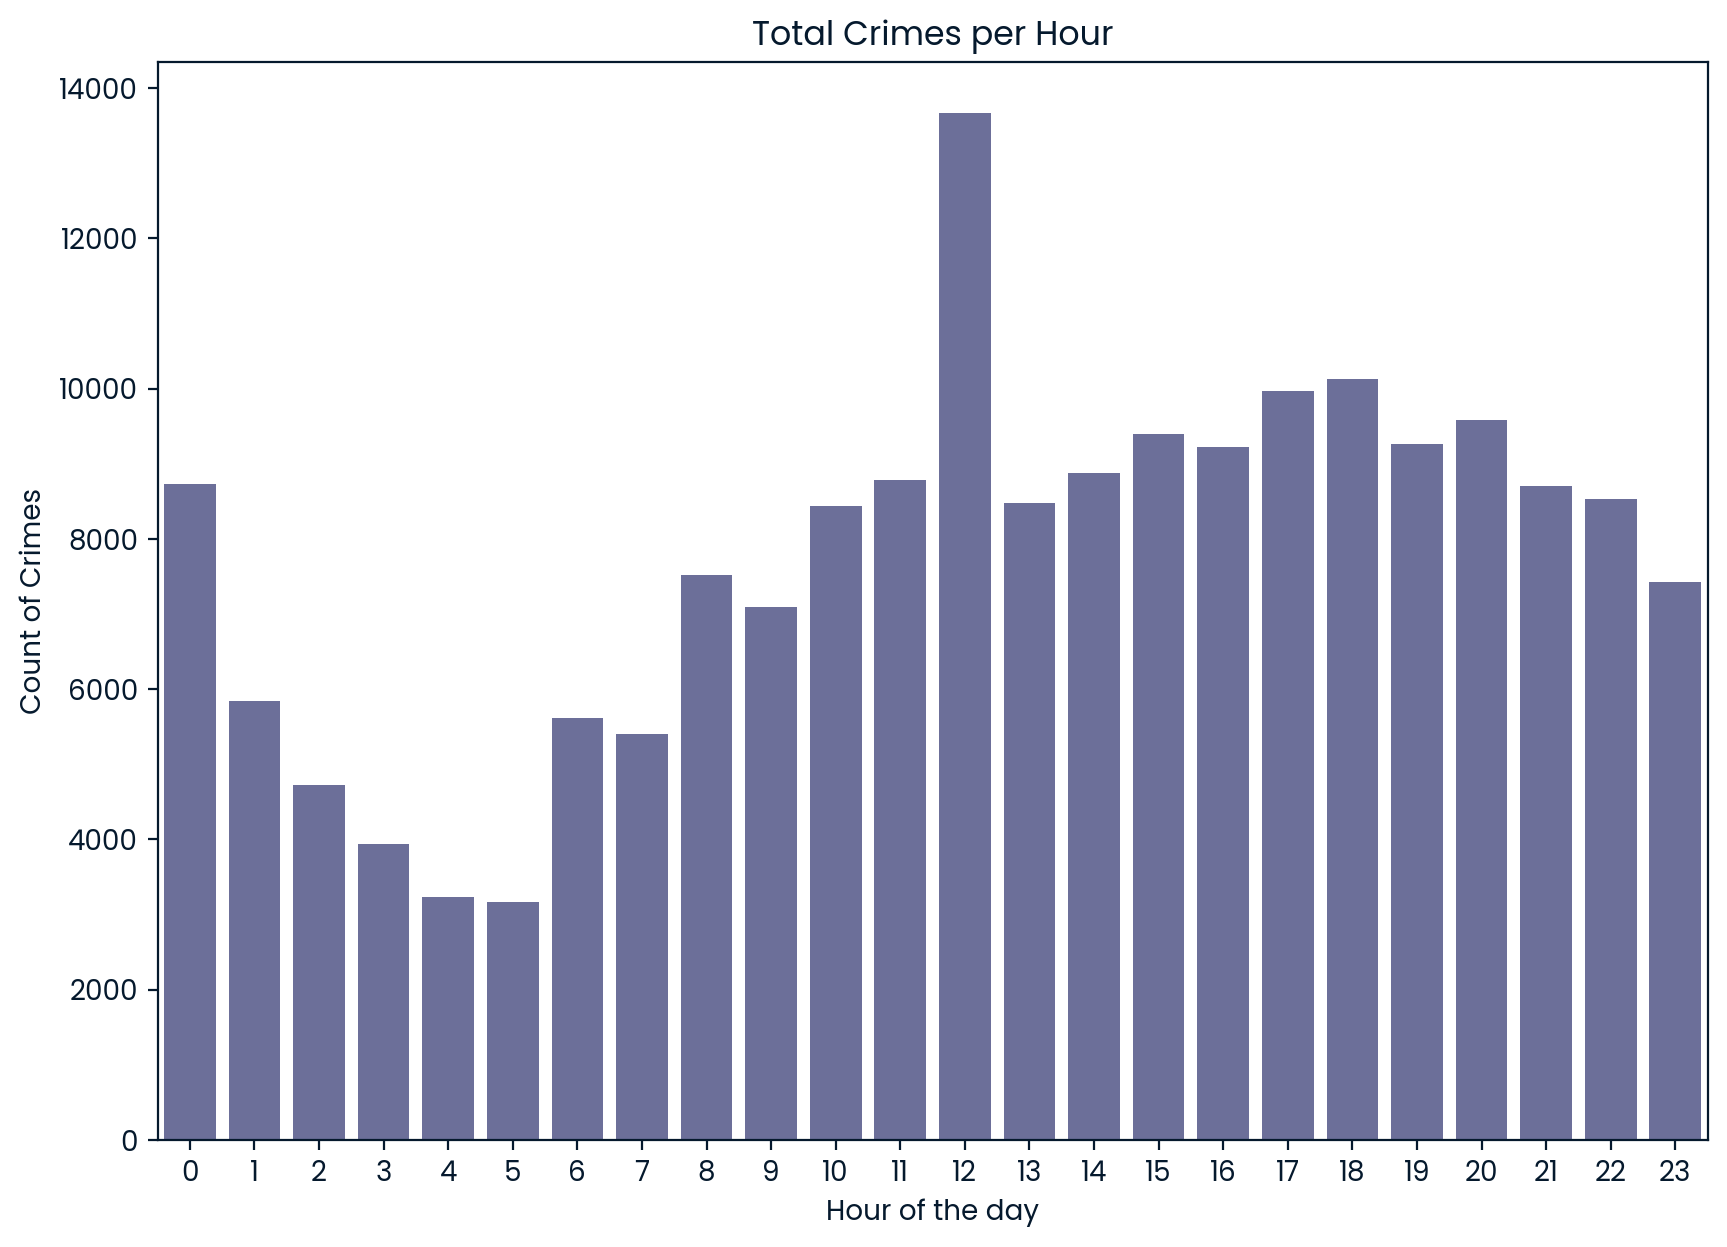

In [47]:
plt.figure(figsize = (10, 7))
sns.countplot(data = crimes, x= 'HOUR OCC')
plt.xlabel('Hour of the day')
plt.ylabel('Count of Crimes')
plt.title('Total Crimes per Hour')
plt.show()

In [48]:
peak_crime_hour = crimes['HOUR OCC'].value_counts().idxmax()
peak_crime_hour

12

In [49]:
# Define night hours: 22 (10pm) to 23 (11pm), 0 (midnight) to 3 (3:59am)
night_hours = list(range(22, 24)) + list(range(0, 4))

In [50]:
# Filter crimes that occurred during night hours
night_crimes = crimes[crimes['HOUR OCC'].isin(night_hours)]

In [51]:
# Find the area with the most night crimes
peak_night_crime_location = night_crimes['AREA NAME'].value_counts().idxmax()
peak_night_crime_location

'Central'

<AxesSubplot: xlabel='Vict Age'>

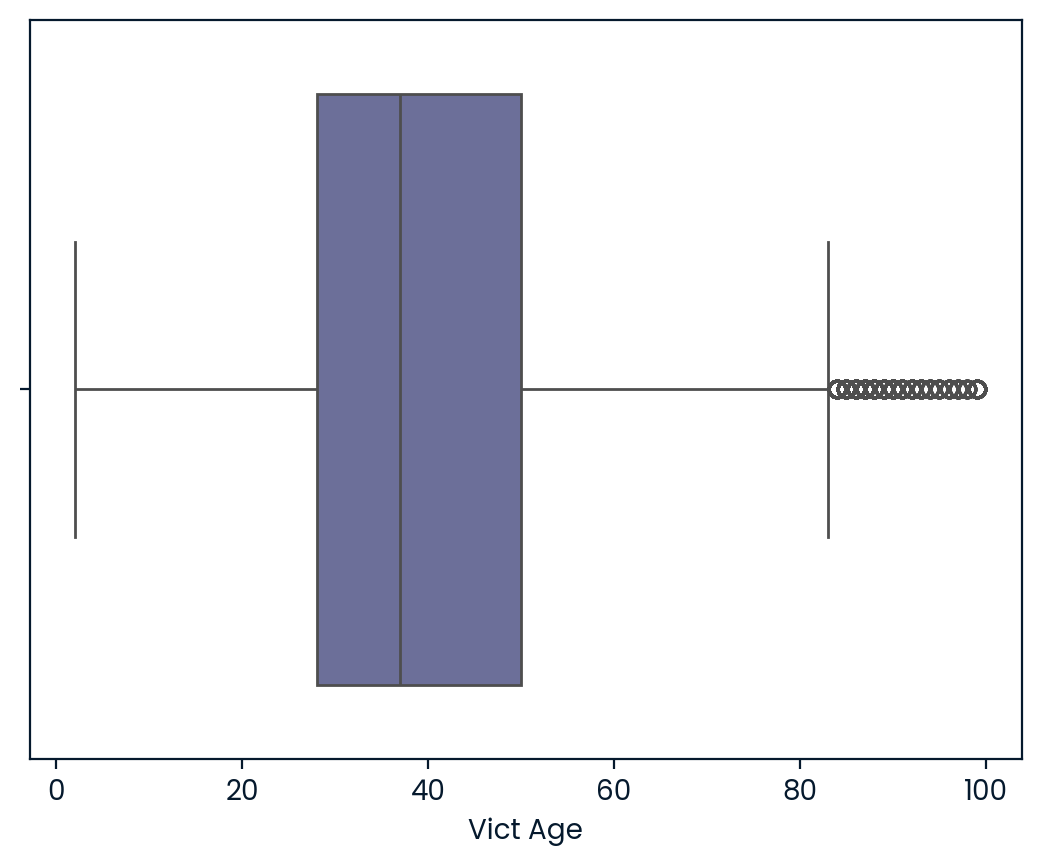

In [52]:
sns.boxplot(data = crimes, x = 'Vict Age')

In [53]:
twenty_fifth = crimes['Vict Age'].quantile(0.25)
seventy_fifth = crimes['Vict Age'].quantile(0.75)
median_age = crimes['Vict Age'].median()
max_age = crimes['Vict Age'].max()
min_age = crimes['Vict Age'].min()
print(f'The 25th percentile is {twenty_fifth}, 75th percentile is {seventy_fifth}, minimum age is {min_age} , maximum age is {max_age} and median age is {median_age}')


The 25th percentile is 28.0, 75th percentile is 50.0, minimum age is 2 , maximum age is 99 and median age is 37.0


In [54]:
# Exclude negative ages before binning
valid_crimes = crimes[crimes['Vict Age'] >= 0]

# Define age bins and labels
age_bins = [0, 17, 25, 34, 44, 54, 64, np.inf]
age_labels = ['0-17', '18-25', '26-34', '35-44', '45-54', '55-64', '65+']

# Bin and label victim ages
valid_crimes['Age Bracket'] = pd.cut(valid_crimes['Vict Age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

# Count crimes by age group
victim_ages = valid_crimes['Age Bracket'].value_counts().sort_index()
victim_ages

0-17      4528
18-25    28291
26-34    47470
35-44    42157
45-54    28353
55-64    20169
65+      14747
Name: Age Bracket, dtype: int64